# BT5153 Group 4 - Modeling Pipeline (No Insights/Visualization Write-up)

This notebook is designed to cover modeling, feature analysis, and evaluation artifacts for the final report rubric using the cleaned dataset already produced.

Scope intentionally excludes business insight narration and advanced visualization polish (handled by teammate).

## 1) Setup

In [13]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

SEED = 42
MAX_ROWS = 300_000
MAX_BAD_SAMPLE = 50_000
RUN_BERTOPIC = False

DATA_FILE = Path('/Users/meghana/Downloads/BT5153-team04-main/electronics_filtered.csv')
META_FILE = Path('/Users/meghana/Downloads/BT5153-team04-main/electronics_metadata.csv')

assert DATA_FILE.exists(), 'Missing electronics_filtered.csv in workspace root'
assert META_FILE.exists(), 'Missing electronics_metadata.csv in workspace root'

print('Found files:', DATA_FILE, META_FILE)
print('Row cap for stable execution:', MAX_ROWS)

Found files: /Users/meghana/Downloads/BT5153-team04-main/electronics_filtered.csv /Users/meghana/Downloads/BT5153-team04-main/electronics_metadata.csv
Row cap for stable execution: 300000


## 2) Load Data and Build Labels

In [14]:
pdf = pd.read_csv(
    DATA_FILE,
    nrows=MAX_ROWS,
    dtype={'asin': 'string'},
    usecols=['asin', 'overall', 'reviewText', 'summary', 'verified']
 )

pdf['summary'] = pdf['summary'].fillna('').astype(str)
pdf['reviewText'] = pdf['reviewText'].fillna('').astype(str)
pdf['verified'] = pdf['verified'].fillna(False).astype(bool)
pdf['text'] = (pdf['summary'] + ' ' + pdf['reviewText']).str.strip()
pdf['word_len'] = pdf['reviewText'].str.count(r'\S+')

# Rating-driven labels (no separate sentiment model needed).
pdf['is_bad_review'] = pdf['overall'] <= 2
pdf['is_good_review'] = pdf['overall'] >= 4

print('Shape:', pdf.shape)
print('Bad review rate (overall<=2):', round(pdf['is_bad_review'].mean(), 4))
print('Good review rate (overall>=4):', round(pdf['is_good_review'].mean(), 4))

Shape: (300000, 9)
Bad review rate (overall<=2): 0.1861
Good review rate (overall>=4): 0.7278


## 3) Feature Analysis (No business insight write-up)

In [15]:
feature_summary = (
    pdf.groupby('is_bad_review', as_index=False)
       .agg(
           n=('is_bad_review', 'size'),
           avg_word_len=('word_len', 'mean'),
           med_word_len=('word_len', 'median'),
           verified_rate=('verified', 'mean')
       )
)
feature_summary['group'] = feature_summary['is_bad_review'].map({True: 'bad_review(overall<=2)', False: 'non_bad_review(overall>2)'})
feature_summary['verified_rate'] = feature_summary['verified_rate'].round(4)
feature_summary['avg_word_len'] = feature_summary['avg_word_len'].round(2)
print('Basic feature summary by rating-driven review group:')
display(feature_summary[['group', 'n', 'avg_word_len', 'med_word_len', 'verified_rate']])

Basic feature summary by rating-driven review group:


,group,n,avg_word_len,med_word_len,verified_rate
0,non_bad_review(overall>2),244167,84.44,50.0,0.8611
1,bad_review(overall<=2),55833,87.10,57.0,0.8188


In [16]:
# Frequent terms in bad vs non-bad reviews (rating-driven, no supervised sentiment model).
sample_for_terms = pdf.sample(n=min(120000, len(pdf)), random_state=SEED).copy()

vec = CountVectorizer(min_df=10, max_df=0.8, ngram_range=(1, 2), stop_words='english')
X_terms = vec.fit_transform(sample_for_terms['text'])
feature_names = np.array(vec.get_feature_names_out())

is_bad = sample_for_terms['is_bad_review'].to_numpy()
bad_counts = np.asarray(X_terms[is_bad].sum(axis=0)).ravel()
non_bad_counts = np.asarray(X_terms[~is_bad].sum(axis=0)).ravel()

top_bad_idx = np.argsort(bad_counts)[-20:][::-1]
top_non_bad_idx = np.argsort(non_bad_counts)[-20:][::-1]

top_terms_df = pd.DataFrame({
    'bad_review_top_terms': feature_names[top_bad_idx],
    'non_bad_review_top_terms': feature_names[top_non_bad_idx],
})
display(top_terms_df)

,bad_review_top_terms,non_bad_review_top_terms
0,work,great
1,just,good
2,product,use
3,use,just
4,good,like
5,like,works
6,time,sound
7,don,price
8,buy,quality
9,quality,product


## 4) Product-Level Rating Summary (No Sentiment Model)

In [18]:
product_stats = (
    pdf.groupby('asin', as_index=False)
      .agg(
          reviews=('overall', 'size'),
          avg_rating=('overall', 'mean'),
          bad_review_rate=('is_bad_review', 'mean'),
          good_review_rate=('is_good_review', 'mean'),
          verified_rate=('verified', 'mean')
      )
)

meta = pd.read_csv(
    META_FILE,
    dtype={'asin': 'string'},
    usecols=['asin', 'title', 'brand', 'avg_rating', 'review_count']
 )

product_stats = product_stats.merge(
    meta[['asin', 'title', 'brand']],
    on='asin',
    how='left'
 )

product_stats['avg_rating'] = product_stats['avg_rating'].round(3)
product_stats['bad_review_rate'] = product_stats['bad_review_rate'].round(3)
product_stats['good_review_rate'] = product_stats['good_review_rate'].round(3)
product_stats['verified_rate'] = product_stats['verified_rate'].round(3)

product_stats['quality_band'] = np.select(
    [product_stats['avg_rating'] <= 2.0, product_stats['avg_rating'] >= 4.0],
    ['bad_product', 'good_product'],
    default='mid_product'
 )

quality_summary = product_stats['quality_band'].value_counts().rename_axis('quality_band').reset_index(name='n_products')
print('Product quality band counts:')
display(quality_summary)

Product quality band counts:


,quality_band,n_products
0,good_product,453
1,mid_product,400


In [28]:
print('Top bad products (avg_rating <= 2):')
bad_products = product_stats.loc[product_stats['avg_rating'] <= 2.0].copy()
bad_products = bad_products.sort_values(['avg_rating', 'reviews', 'bad_review_rate'], ascending=[True, False, False])
display(bad_products[['asin', 'title', 'brand', 'reviews', 'avg_rating', 'bad_review_rate', 'verified_rate']].head(30))

print('Top good products (avg_rating >= 4):')
good_products = product_stats.loc[product_stats['avg_rating'] >= 4.0].copy()
good_products = good_products.sort_values(['avg_rating', 'reviews'], ascending=[False, False])
display(good_products[['asin', 'title', 'brand', 'reviews', 'avg_rating', 'good_review_rate', 'verified_rate']].head(30))

Top bad products (avg_rating <= 2):


,asin,title,brand,reviews,avg_rating,bad_review_rate,verified_rate


Top good products (avg_rating >= 4):


,asin,title,brand,reviews,avg_rating,good_review_rate,verified_rate
47,B0000DYV9N,Pelican 1500 Camera Case With Foam (Silver),Pelican,231,4.922,0.991,0.948
48,B0000DYV9N,Pelican 1500 Camera Case With Foam (Silver),Pelican,231,4.922,0.991,0.948
157,B000WU2LXC,"ARCTIC MX-2 - Thermal Compound Paste, Carbon B...",ARCTIC,500,4.792,0.956,0.900
370,B005C50H2Y,Nikon AF-S DX Micro-NIKKOR 40mm f/2.8G Close-u...,Nikon,221,4.792,0.968,0.851
330,B004EBX5GW,Mediabridge ULTRA Series RCA Y-Adapter (12 Inc...,Mediabridge,269,4.788,0.963,0.974
440,B007JPCL88,TiVo Premiere 500 GB DVR (Old Version) - Digit...,TiVo,500,4.774,0.986,0.044
268,B002EEP3MK,"OPPO BDP-83 Blu-ray Disc Player with SACD, DV...",OPPO Digital,295,4.773,0.942,0.759
632,B00K4NVRRI,The Friendly Swede Replaceable Micro-Knit Tip ...,The Friendly Swede,500,4.768,0.956,0.954
204,B0017I3K9M,Viewsonics VSIS-EU Cable TV Ground Loop Isolator,Viewsonics,500,4.762,0.938,0.958
234,B001MX5YWI,Crucial 8GB Kit (4GBx2) DDR3 1066 MT/s (PC3-85...,Crucial,500,4.754,0.940,0.956


In [9]:
# Artifact for teammate: product-level table with names and quality labels.
product_quality_artifact = product_stats[[
    'asin', 'title', 'brand', 'reviews', 'avg_rating', 'bad_review_rate', 'good_review_rate', 'quality_band'
]].copy()

product_quality_artifact = product_quality_artifact.sort_values(
    ['quality_band', 'avg_rating', 'reviews'],
    ascending=[True, True, False]
).reset_index(drop=True)

print('Product quality artifact preview (ready for teammate use):')
display(product_quality_artifact.head(30))

Product quality artifact preview (ready for teammate use):


,asin,title,brand,reviews,avg_rating,bad_review_rate,good_review_rate,quality_band
0,B005HJWWW8,Compatible 2 in 1 Charger and Headphones Adapt...,EldHus,500,4.000,0.170,0.738,good_product
1,B01CCMUN8C,EDUP WiFi Adapter ac600Mbps Wireless USB Adapt...,EDUP,460,4.000,0.215,0.737,good_product
2,B009Y9O6NK,Apple iPad mini Smart Cover (Light Gray) - MD9...,Apple,346,4.000,0.188,0.728,good_product
3,B00BCPH3YS,Samsung PN64F8500 64-Inch 1080p 600Hz 3D Smart...,Samsung,373,4.003,0.212,0.740,good_product
4,B00114ZT78,Board Dudes 18&quot; x 22&quot; Magnetic Dry E...,The Board Dudes,217,4.005,0.161,0.737,good_product
5,B00PC9HFO8,Dell Ultra HD 4k Monitor P2715Q 27-Inch Screen...,Dell,500,4.006,0.180,0.726,good_product
6,B01EC7AGVE,COMISO Portable Bluetooth 360&deg; Speaker wit...,COMISO,476,4.008,0.204,0.742,good_product
7,B00064V6RG,SanDisk ImageMate 12-in-1 USB 2.0 Flash Memory...,SanDisk,277,4.011,0.184,0.762,good_product
8,B0170MA9VU,"iPad Pro Case, SUPCASE [Heavy Duty] Apple iPad...",SUPCASE,237,4.013,0.169,0.730,good_product
9,B0000A1VS3,Nikon 25604 UC-E6 USB Cable,Nikon,433,4.014,0.206,0.760,good_product


## 5) Topic Modeling on Bad Reviews (overall <= 2)

In [19]:
bad_reviews = pdf.loc[pdf['is_bad_review'], 'text'].dropna()
bad_reviews = bad_reviews[bad_reviews.str.len() > 30]

bad_sample = bad_reviews.sample(n=min(MAX_BAD_SAMPLE, len(bad_reviews)), random_state=SEED)
print('Bad review sample size for topic models:', len(bad_sample))

Bad review sample size for topic models: 50000


In [20]:
n_topics = 12
count_vec = CountVectorizer(min_df=20, max_df=0.7, stop_words='english')
X_bad_count = count_vec.fit_transform(bad_sample)

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=SEED,
    learning_method='batch',
    max_iter=20
)
lda.fit(X_bad_count)

tfidf_vec = TfidfVectorizer(min_df=20, max_df=0.7, stop_words='english')
X_bad_tfidf = tfidf_vec.fit_transform(bad_sample)

nmf = NMF(n_components=n_topics, random_state=SEED, init='nndsvda', max_iter=300)
nmf.fit(X_bad_tfidf)

print('LDA and NMF fitted on bad reviews.')

LDA and NMF fitted on bad reviews.


In [22]:
def get_top_words(model, feature_names, n_top_words=12):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_idx = np.argsort(topic)[-n_top_words:][::-1]
        topics.append([feature_names[i] for i in top_idx])
    return topics

lda_topics = get_top_words(lda, count_vec.get_feature_names_out())
nmf_topics = get_top_words(nmf, tfidf_vec.get_feature_names_out())

lda_topics_df = pd.DataFrame({'topic_id': range(len(lda_topics)), 'top_words': [' | '.join(t) for t in lda_topics]})
nmf_topics_df = pd.DataFrame({'topic_id': range(len(nmf_topics)), 'top_words': [' | '.join(t) for t in nmf_topics]})

print('LDA Topics')
display(lda_topics_df)
print('NMF Topics')
display(nmf_topics_df)

LDA Topics


,topic_id,top_words
0,0,battery | charge | player | time | ipod | use ...
1,1,case | ipad | keyboard | fit | like | does | c...
2,2,camera | tv | picture | video | quality | pict...
3,3,drive | computer | windows | usb | work | soft...
4,4,months | product | working | amazon | worked |...
5,5,screen | product | plastic | like | item | box...
6,6,sound | quality | good | speaker | speakers | ...
7,7,headphones | mouse | ear | use | pair | good |...
8,8,money | buy | don | waste | work | product | j...
9,9,router | support | device | wireless | connect...


NMF Topics


,topic_id,top_words
0,0,work | did | didn | does | doesn | tried | ret...
1,1,sound | quality | headphones | ear | good | pa...
2,2,working | stopped | months | worked | great | ...
3,3,camera | pictures | lens | canon | card | vide...
4,4,case | ipad | fit | screen | cover | like | do...
5,5,money | waste | don | buy | time | junk | wort...
6,6,tv | samsung | remote | screen | picture | pla...
7,7,router | drive | device | card | support | tim...
8,8,battery | charge | charger | life | charging |...
9,9,product | item | amazon | buy | return | recei...


In [23]:
# Topic diversity as proportion of unique words among all top-k topic words.
def topic_diversity(topics, top_k=10):
    words = []
    for t in topics:
        words.extend(t[:top_k])
    return len(set(words)) / len(words)

div_lda = topic_diversity(lda_topics, top_k=10)
div_nmf = topic_diversity(nmf_topics, top_k=10)

topic_quality_df = pd.DataFrame([
    {'model': 'LDA', 'topic_diversity@10': div_lda},
    {'model': 'NMF', 'topic_diversity@10': div_nmf},
])
display(topic_quality_df)

,model,topic_diversity@10
0,LDA,0.808333
1,NMF,0.883333


## 6) Optional BERTopic on Bad Reviews (Run only if package available)

In [24]:
# Optional: BERTopic on bad reviews, guarded to avoid breaking notebook if package is unavailable.
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer

    bt_sample = bad_sample.sample(min(10000, len(bad_sample)), random_state=SEED).tolist()
    emb_model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = emb_model.encode(bt_sample, show_progress_bar=True, batch_size=256)

    topic_model = BERTopic(
        min_topic_size=100,
        calculate_probabilities=False,
        verbose=True
    )
    bt_topics, _ = topic_model.fit_transform(bt_sample, embeddings)

    bt_info = topic_model.get_topic_info().head(20)
    display(bt_info)
    print('BERTopic completed on bad-review text.')
except Exception as e:
    print('BERTopic not run:', e)
    print('This does not block the rest of the notebook.')

BERTopic not run: No module named 'bertopic'
This does not block the rest of the notebook.


## 7) Product-Level Action Artifact (for teammate handoff)

In [13]:
handoff_table = product_stats[[
    'asin', 'title', 'brand', 'reviews', 'avg_rating', 'quality_band',
    'bad_review_rate', 'good_review_rate', 'verified_rate'
]].copy()

handoff_table = handoff_table.sort_values(
    ['quality_band', 'avg_rating', 'reviews'],
    ascending=[True, True, False]
).reset_index(drop=True)

print('Handoff table counts by quality band:')
print(handoff_table['quality_band'].value_counts())
display(handoff_table.head(30))

Handoff table counts by quality band:
quality_band
good_product    453
mid_product     400
Name: count, dtype: int64


,asin,title,brand,reviews,avg_rating,quality_band,bad_review_rate,good_review_rate,verified_rate
0,B005HJWWW8,Compatible 2 in 1 Charger and Headphones Adapt...,EldHus,500,4.000,good_product,0.170,0.738,0.932
1,B01CCMUN8C,EDUP WiFi Adapter ac600Mbps Wireless USB Adapt...,EDUP,460,4.000,good_product,0.215,0.737,0.970
2,B009Y9O6NK,Apple iPad mini Smart Cover (Light Gray) - MD9...,Apple,346,4.000,good_product,0.188,0.728,0.945
3,B00BCPH3YS,Samsung PN64F8500 64-Inch 1080p 600Hz 3D Smart...,Samsung,373,4.003,good_product,0.212,0.740,0.694
4,B00114ZT78,Board Dudes 18&quot; x 22&quot; Magnetic Dry E...,The Board Dudes,217,4.005,good_product,0.161,0.737,0.917
5,B00PC9HFO8,Dell Ultra HD 4k Monitor P2715Q 27-Inch Screen...,Dell,500,4.006,good_product,0.180,0.726,0.866
6,B01EC7AGVE,COMISO Portable Bluetooth 360&deg; Speaker wit...,COMISO,476,4.008,good_product,0.204,0.742,0.878
7,B00064V6RG,SanDisk ImageMate 12-in-1 USB 2.0 Flash Memory...,SanDisk,277,4.011,good_product,0.184,0.762,0.567
8,B0170MA9VU,"iPad Pro Case, SUPCASE [Heavy Duty] Apple iPad...",SUPCASE,237,4.013,good_product,0.169,0.730,0.970
9,B0000A1VS3,Nikon 25604 UC-E6 USB Cable,Nikon,433,4.014,good_product,0.206,0.760,0.956


## 8) Simple Product Quality Dashboard (Table-based)

In [25]:
import ipywidgets as widgets
from IPython.display import display, clear_output

dash_df = product_stats.copy()
dash_df['title'] = dash_df['title'].fillna('')
dash_df['brand'] = dash_df['brand'].fillna('')

brand_options = ['ALL'] + sorted([b for b in dash_df['brand'].astype(str).replace('', np.nan).dropna().unique()][:300])
quality_options = ['ALL', 'bad_product', 'mid_product', 'good_product']

brand_dd = widgets.Dropdown(options=brand_options, value='ALL', description='Brand:')
quality_dd = widgets.Dropdown(options=quality_options, value='ALL', description='Quality:')
topn = widgets.IntSlider(value=10, min=5, max=30, step=1, description='Top N:')
sort_by = widgets.Dropdown(
    options=['avg_rating_asc', 'avg_rating_desc', 'bad_review_rate_desc', 'reviews_desc'],
    value='avg_rating_asc',
    description='Sort:'
)
out = widgets.Output()

def render(_=None):
    with out:
        clear_output(wait=True)
        d = dash_df.copy()

        if brand_dd.value != 'ALL':
            d = d[d['brand'].astype(str) == brand_dd.value]
        if quality_dd.value != 'ALL':
            d = d[d['quality_band'] == quality_dd.value]

        if len(d) == 0:
            print('No rows for this filter.')
            return

        if sort_by.value == 'avg_rating_asc':
            d = d.sort_values(['avg_rating', 'reviews'], ascending=[True, False])
        elif sort_by.value == 'avg_rating_desc':
            d = d.sort_values(['avg_rating', 'reviews'], ascending=[False, False])
        elif sort_by.value == 'bad_review_rate_desc':
            d = d.sort_values(['bad_review_rate', 'reviews'], ascending=[False, False])
        else:
            d = d.sort_values(['reviews', 'avg_rating'], ascending=[False, False])

        view = d[['asin', 'title', 'brand', 'reviews', 'avg_rating', 'quality_band', 'bad_review_rate', 'good_review_rate', 'verified_rate']].head(topn.value).copy()
        view['avg_rating'] = view['avg_rating'].round(3)
        view['bad_review_rate'] = view['bad_review_rate'].round(3)
        view['good_review_rate'] = view['good_review_rate'].round(3)
        view['verified_rate'] = view['verified_rate'].round(3)
        display(view)

brand_dd.observe(render, names='value')
quality_dd.observe(render, names='value')
topn.observe(render, names='value')
sort_by.observe(render, names='value')

display(widgets.HBox([brand_dd, quality_dd]))
display(widgets.HBox([sort_by, topn]))
display(out)
render()

Output()

## 9) Rubric Checklist Artifact (Rating-Driven Pipeline)

In [15]:
rubric_checklist = pd.DataFrame([
    ['Clarity/completeness', 'Data loading, rating-based grouping, and product-level aggregation documented'],
    ['Appropriate modeling scope', 'No redundant sentiment classifier; uses ground-truth rating thresholds directly'],
    ['Coherence with hypotheses', 'Bad-product identification and complaint-theme modeling aligned with objective'],
    ['Real-world usefulness', 'Product-level handoff table with avg rating, quality band, and bad-review rate'],
    ['Concise summarization support', 'Quality-band counts, top bad/good product tables, and dashboard outputs generated'],
    ['Advantages/limitations discussion support', 'Topic-model outputs on bad reviews and optional BERTopic fallback documented']
], columns=['Rubric item', 'Notebook evidence'])
display(rubric_checklist)

,Rubric item,Notebook evidence
0,Clarity/completeness,"Data loading, rating-based grouping, and produ..."
1,Appropriate modeling scope,No redundant sentiment classifier; uses ground...
2,Coherence with hypotheses,Bad-product identification and complaint-theme...
3,Real-world usefulness,"Product-level handoff table with avg rating, q..."
4,Concise summarization support,"Quality-band counts, top bad/good product tabl..."
5,Advantages/limitations discussion support,Topic-model outputs on bad reviews and optiona...


## 10) Baseline Insights
> Quick, non-interpretive insights generated from rating-driven outputs.

In [29]:
insights_starter = pd.DataFrame([
    ['Sample rows used', len(pdf)],
    ['Unique products in sample', int(pdf['asin'].nunique())],
    ['Bad review rate (overall<=2)', round(float(pdf['is_bad_review'].mean()), 4)],
    ['Good review rate (overall>=4)', round(float(pdf['is_good_review'].mean()), 4)],
    ['Products labeled bad_product (avg<=2)', int((product_stats['quality_band'] == 'bad_product').sum())],
    ['Products labeled good_product (avg>=4)', int((product_stats['quality_band'] == 'good_product').sum())],
    ['Topic diversity@10 (LDA)', round(float(div_lda), 4)],
    ['Topic diversity@10 (NMF)', round(float(div_nmf), 4)],
], columns=['Metric', 'Value'])

display(insights_starter)

print('Top 10 brands by bad review rate (min 200 reviews in sample):')
brand_insights = (
    pdf.groupby('brand', as_index=False) if 'brand' in pdf.columns else None
)
if brand_insights is None:
    tmp = product_stats.groupby('brand', as_index=False).agg(
        products=('asin', 'nunique'),
        total_reviews=('reviews', 'sum'),
        avg_bad_rate=('bad_review_rate', 'mean'),
        avg_rating=('avg_rating', 'mean')
    )
else:
    tmp = brand_insights

brand_summary = (
    product_stats.groupby('brand', as_index=False)
      .agg(
          products=('asin', 'nunique'),
          total_reviews=('reviews', 'sum'),
          avg_bad_rate=('bad_review_rate', 'mean'),
          avg_rating=('avg_rating', 'mean')
      )
      .query('total_reviews >= 200')
      .sort_values(['avg_bad_rate', 'total_reviews'], ascending=[False, False])
      .head(10)
      .reset_index(drop=True)
 )
brand_summary['avg_bad_rate'] = brand_summary['avg_bad_rate'].round(3)
brand_summary['avg_rating'] = brand_summary['avg_rating'].round(3)
display(brand_summary)

,Metric,Value
0,Sample rows used,300000.0000
1,Unique products in sample,814.0000
2,Bad review rate (overall<=2),0.1861
3,Good review rate (overall>=4),0.7278
4,Products labeled bad_product (avg<=2),0.0000
5,Products labeled good_product (avg>=4),453.0000
6,Topic diversity@10 (LDA),0.8083
7,Topic diversity@10 (NMF),0.8833


Top 10 brands by bad review rate (min 200 reviews in sample):


,brand,products,total_reviews,avg_bad_rate,avg_rating
0,Tagital,1,317,0.688,2.161
1,JLAB,1,500,0.550,2.610
2,Jabra,1,335,0.549,2.633
3,Zeikos,1,364,0.514,2.775
4,Besdata,1,500,0.500,2.742
5,Lexar,1,500,0.496,2.908
6,Access HD,1,266,0.492,2.684
7,XO Vision,1,500,0.458,2.784
8,Blue Donuts,1,500,0.450,2.864
9,Griffin Technology,2,1252,0.438,2.961


## 11) Visualization Starter


> Basic plots only; teammate can improve narrative, style, and interactivity.

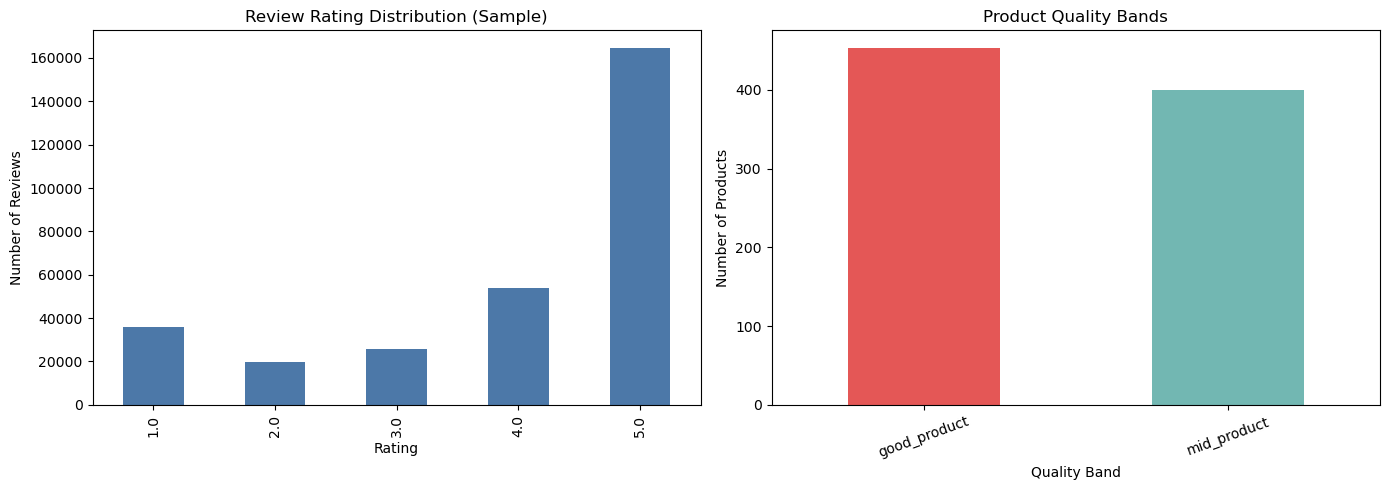

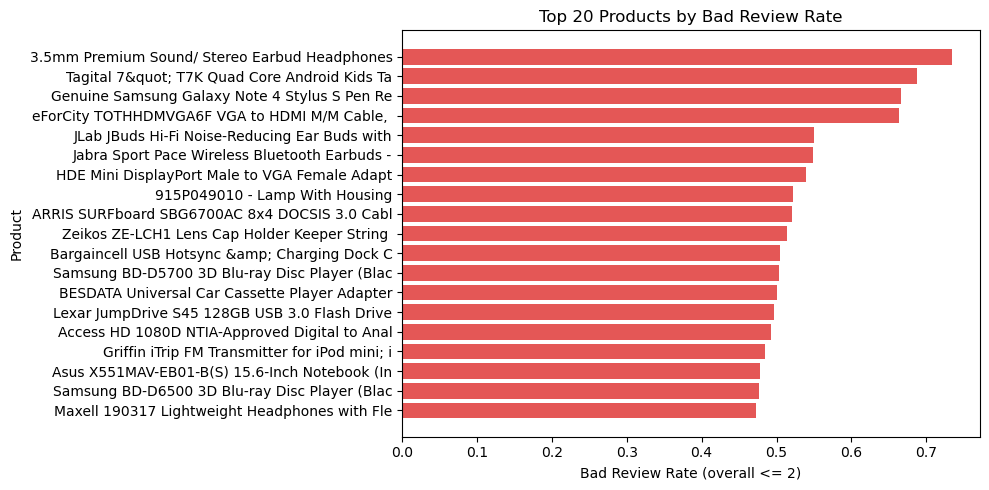

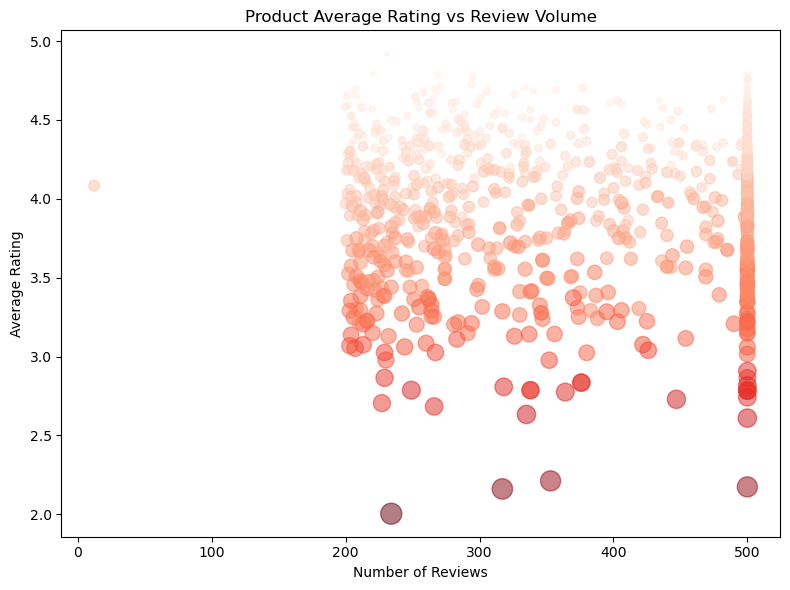

In [27]:
import matplotlib.pyplot as plt

# Use default style since seaborn-v0_8-whitegrid is not available
plt.style.use('default')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1) Overall rating distribution
pdf['overall'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#4C78A8')
ax[0].set_title('Review Rating Distribution (Sample)')
ax[0].set_xlabel('Rating')
ax[0].set_ylabel('Number of Reviews')

# 2) Product quality bands
quality_counts = product_stats['quality_band'].value_counts()
quality_counts.plot(kind='bar', ax=ax[1], color=['#E45756', '#72B7B2', '#54A24B'])
ax[1].set_title('Product Quality Bands')
ax[1].set_xlabel('Quality Band')
ax[1].set_ylabel('Number of Products')
ax[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
top_bad = product_stats.sort_values('bad_review_rate', ascending=False).head(20).copy()
top_bad = top_bad.sort_values('bad_review_rate', ascending=True)
labels = top_bad['title'].fillna(top_bad['asin']).astype(str).str.slice(0, 45)
ax.barh(labels, top_bad['bad_review_rate'], color='#E45756')
ax.set_title('Top 20 Products by Bad Review Rate')
ax.set_xlabel('Bad Review Rate (overall <= 2)')
ax.set_ylabel('Product')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    product_stats['reviews'],
    product_stats['avg_rating'],
    s=(product_stats['bad_review_rate'] * 300 + 10),
    alpha=0.5,
    c=product_stats['bad_review_rate'],
    cmap='Reds'
 )
ax.set_title('Product Average Rating vs Review Volume')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plt.show()

Review Length Distribution by Rating

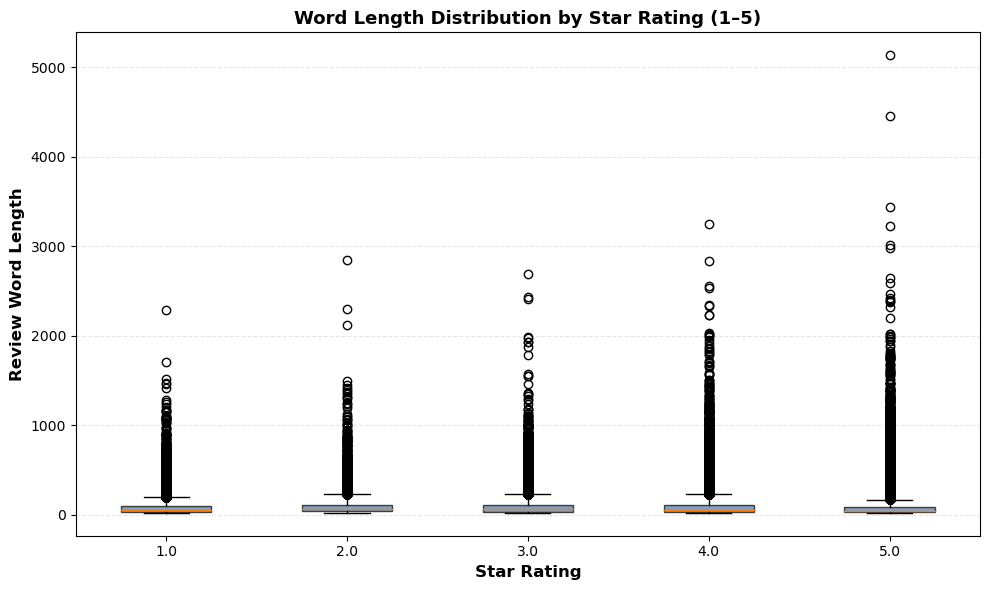

Box plot generated: word_len distribution by rating.


In [32]:
import matplotlib.pyplot as plt
from scipy import stats

# Box plot: word_len distribution by star rating (1-5)
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for each rating
ratings = sorted(pdf['overall'].unique())
data_by_rating = [pdf[pdf['overall'] == rating]['word_len'].values for rating in ratings]

# Create box plot
bp = ax.boxplot(data_by_rating, labels=ratings, patch_artist=True)

# Style the box plot
for patch in bp['boxes']:
    patch.set_facecolor('#4C78A8')
    patch.set_alpha(0.7)

ax.set_xlabel('Star Rating', fontsize=12, fontweight='bold')
ax.set_ylabel('Review Word Length', fontsize=12, fontweight='bold')
ax.set_title('Word Length Distribution by Star Rating (1–5)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print('Box plot generated: word_len distribution by rating.')


### Word Length Distribution: Bad Reviews vs Non-Bad Reviews (KDE)

99th percentile word_len: 522
Rows with word_len capped: 2994


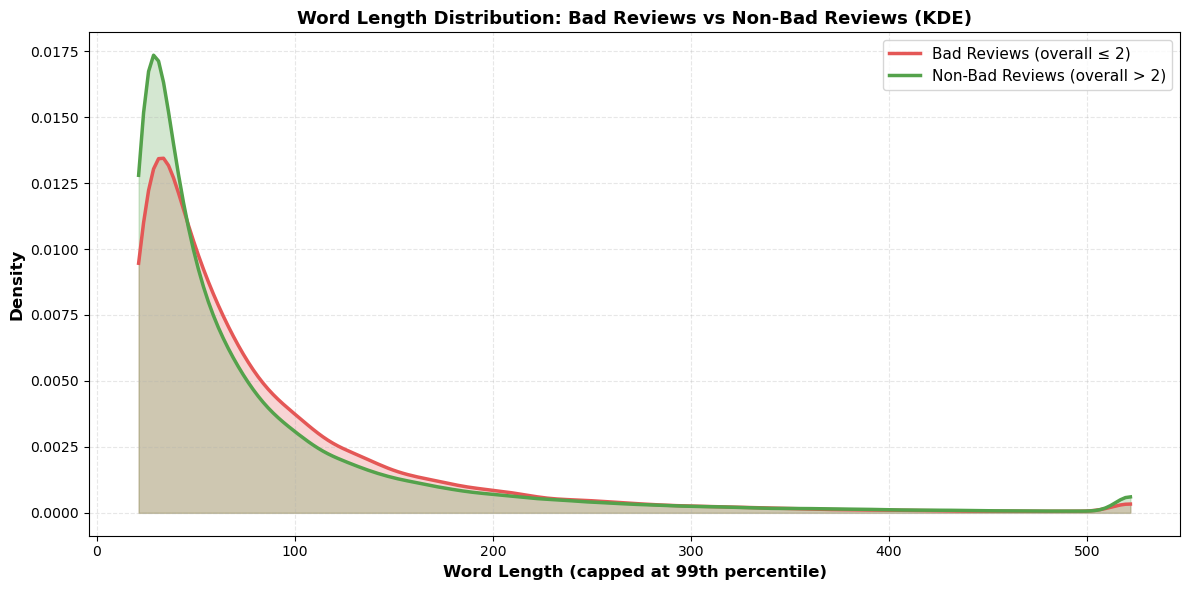


Summary Statistics:
Bad Reviews (overall ≤ 2):
  Mean word_len: 85.46
  Median word_len: 57.00
  Std Dev: 82.07

Non-Bad Reviews (overall > 2):
  Mean word_len: 81.62
  Median word_len: 50.00
  Std Dev: 87.47


In [33]:
import matplotlib.pyplot as plt
from scipy import stats

# Cap word_len at 99th percentile to remove extreme outliers
percentile_99 = pdf['word_len'].quantile(0.99)
pdf_capped = pdf.copy()
pdf_capped['word_len_capped'] = pdf_capped['word_len'].clip(upper=percentile_99)

print(f'99th percentile word_len: {percentile_99:.0f}')
print(f'Rows with word_len capped: {(pdf["word_len"] > percentile_99).sum()}')

# Prepare data for bad and non-bad reviews
bad_review_lengths = pdf_capped[pdf_capped['is_bad_review'] == True]['word_len_capped'].values
non_bad_review_lengths = pdf_capped[pdf_capped['is_bad_review'] == False]['word_len_capped'].values

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Compute KDE for both groups
from scipy.stats import gaussian_kde

# KDE for bad reviews
kde_bad = gaussian_kde(bad_review_lengths)
x_bad = np.linspace(bad_review_lengths.min(), bad_review_lengths.max(), 200)
ax.plot(x_bad, kde_bad(x_bad), label='Bad Reviews (overall ≤ 2)', linewidth=2.5, color='#E45756')
ax.fill_between(x_bad, kde_bad(x_bad), alpha=0.25, color='#E45756')

# KDE for non-bad reviews
kde_non_bad = gaussian_kde(non_bad_review_lengths)
x_non_bad = np.linspace(non_bad_review_lengths.min(), non_bad_review_lengths.max(), 200)
ax.plot(x_non_bad, kde_non_bad(x_non_bad), label='Non-Bad Reviews (overall > 2)', linewidth=2.5, color='#54A24B')
ax.fill_between(x_non_bad, kde_non_bad(x_non_bad), alpha=0.25, color='#54A24B')

# Labels and formatting
ax.set_xlabel('Word Length (capped at 99th percentile)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Word Length Distribution: Bad Reviews vs Non-Bad Reviews (KDE)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print summary statistics
print('\nSummary Statistics:')
print('Bad Reviews (overall ≤ 2):')
print(f'  Mean word_len: {bad_review_lengths.mean():.2f}')
print(f'  Median word_len: {np.median(bad_review_lengths):.2f}')
print(f'  Std Dev: {bad_review_lengths.std():.2f}')
print('\nNon-Bad Reviews (overall > 2):')
print(f'  Mean word_len: {non_bad_review_lengths.mean():.2f}')
print(f'  Median word_len: {np.median(non_bad_review_lengths):.2f}')
print(f'  Std Dev: {non_bad_review_lengths.std():.2f}')


## 12) Verified vs Unverified Reviews Analysis

Grouped breakdown (verified × rating):


,verified,overall,count,proportion
0,False,1.0,6755,0.153376
1,False,2.0,3364,0.076382
2,False,3.0,3788,0.086009
3,False,4.0,7990,0.181418
4,False,5.0,22145,0.502815
5,True,1.0,29295,0.114452
6,True,2.0,16419,0.064147
7,True,3.0,22042,0.086116
8,True,4.0,45837,0.179080
9,True,5.0,142365,0.556205


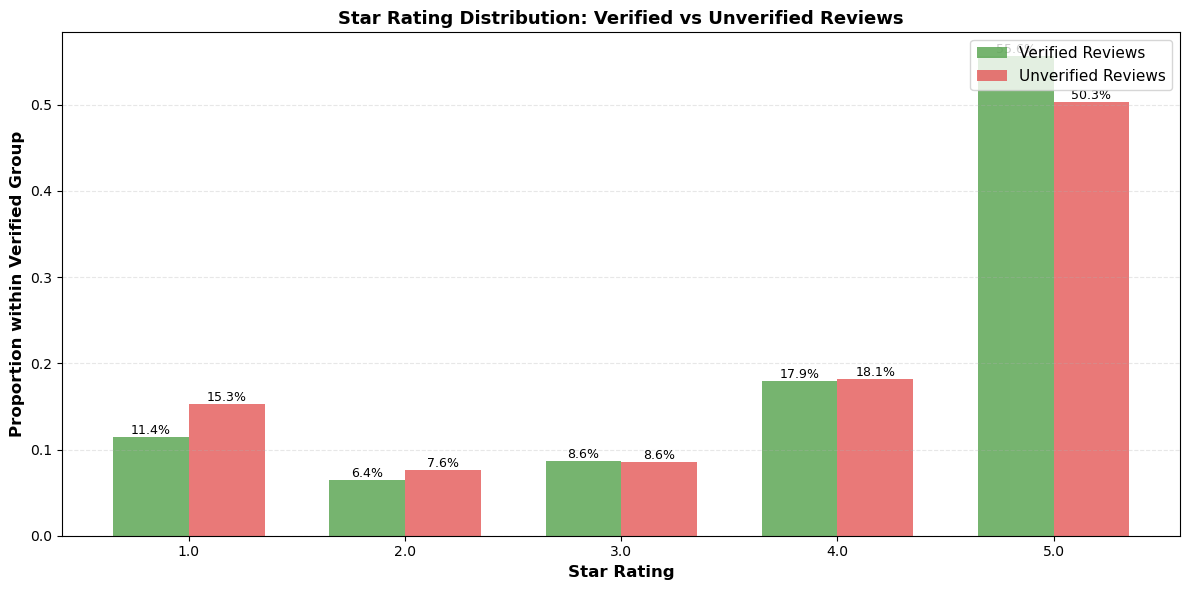

Grouped bar chart: proportion of each star rating by verified status.


In [36]:
import matplotlib.pyplot as plt

# Grouping by verified and overall rating to get counts
groupby_verified_rating = pdf.groupby(['verified', 'overall']).size().reset_index(name='count')

# Calculate proportions: for each verified group, divide by total in that group
verified_totals = pdf.groupby('verified').size()
groupby_verified_rating['proportion'] = groupby_verified_rating.apply(
    lambda row: row['count'] / verified_totals[row['verified']], axis=1
)

print('Grouped breakdown (verified × rating):')
display(groupby_verified_rating)

# Prepare data for grouped bar chart
ratings = sorted(pdf['overall'].unique())
verified_true_props = []
verified_false_props = []

for rating in ratings:
    v_true = groupby_verified_rating[(groupby_verified_rating['verified'] == True) & (groupby_verified_rating['overall'] == rating)]['proportion'].values
    v_false = groupby_verified_rating[(groupby_verified_rating['verified'] == False) & (groupby_verified_rating['overall'] == rating)]['proportion'].values
    
    verified_true_props.append(v_true[0] if len(v_true) > 0 else 0)
    verified_false_props.append(v_false[0] if len(v_false) > 0 else 0)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(ratings))
width = 0.35

bars1 = ax.bar(x - width/2, verified_true_props, width, label='Verified Reviews', color='#54A24B', alpha=0.8)
bars2 = ax.bar(x + width/2, verified_false_props, width, label='Unverified Reviews', color='#E45756', alpha=0.8)

# Labels and formatting
ax.set_xlabel('Star Rating', fontsize=12, fontweight='bold')
ax.set_ylabel('Proportion within Verified Group', fontsize=12, fontweight='bold')
ax.set_title('Star Rating Distribution: Verified vs Unverified Reviews', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ratings)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('Grouped bar chart: proportion of each star rating by verified status.')


In [37]:
# Summary table: verified vs unverified
verified_summary = pdf.groupby('verified').agg(
    count=('verified', 'size'),
    mean_rating=('overall', 'mean'),
    bad_review_rate=('is_bad_review', 'mean'),
    mean_word_len=('word_len', 'mean')
).reset_index()

# Rename and format
verified_summary.columns = ['Verified', 'Review Count', 'Mean Rating', 'Bad Review Rate', 'Mean Word Length']
verified_summary['Verified'] = verified_summary['Verified'].map({True: 'Yes', False: 'No'})
verified_summary['Mean Rating'] = verified_summary['Mean Rating'].round(3)
verified_summary['Bad Review Rate'] = verified_summary['Bad Review Rate'].round(4)
verified_summary['Mean Word Length'] = verified_summary['Mean Word Length'].round(2)

print('Summary Table: Verified vs Unverified Reviews')
display(verified_summary)

# Additional insights
print('\nKey Insights:')
verified_true = pdf[pdf['verified'] == True]
verified_false = pdf[pdf['verified'] == False]

print(f"Verified reviews: {len(verified_true)} ({len(verified_true)/len(pdf)*100:.1f}%)")
print(f"Unverified reviews: {len(verified_false)} ({len(verified_false)/len(pdf)*100:.1f}%)")
print(f"\nRating difference (Verified - Unverified): {verified_true['overall'].mean() - verified_false['overall'].mean():.3f} stars")
print(f"Bad review rate difference: {(verified_true['is_bad_review'].mean() - verified_false['is_bad_review'].mean())*100:.2f}%")
print(f"Word length difference: {verified_true['word_len'].mean() - verified_false['word_len'].mean():.2f} words")


Summary Table: Verified vs Unverified Reviews


,Verified,Review Count,Mean Rating,Bad Review Rate,Mean Word Length
0,No,44042,3.804,0.2298,132.47
1,Yes,255958,3.998,0.1786,76.75



Key Insights:
Verified reviews: 255958 (85.3%)
Unverified reviews: 44042 (14.7%)

Rating difference (Verified - Unverified): 0.195 stars
Bad review rate difference: -5.12%
Word length difference: -55.72 words


Discriminating Terms Visualization (Bad vs Non-Bad)

Top 20 Bad-Skewed Terms (proportionally higher in bad reviews):


,term,lift,bad_count,non_bad_count
30986,junk junk,27071.615570,34,0
4163,avoid product,24682.943608,31,0
68908,work waste,19905.599684,25,0
28612,huge waste,18313.151709,23,0
50072,recourse,18313.151709,23,0
28306,horrible experience,17516.927722,22,0
23557,garbage don,16720.703735,21,0
8164,buy junk,15924.479747,20,0
4159,avoid costs,15128.255760,19,0
4367,awful awful,14332.031773,18,0



Top 20 Good-Skewed Terms (proportionally higher in non-bad reviews):


,term,lift,bad_count,non_bad_count
11,000 000,0.0,0,29
12,000 miles,0.0,0,12
13,000 photos,0.0,0,11
63,10 great,0.0,0,14
72,10 laptop,0.0,0,12
99,10 sound,0.0,0,15
111,10 works,0.0,0,32
125,100 cable,0.0,0,11
143,100 month,0.0,0,11
145,100 percent,0.0,0,18


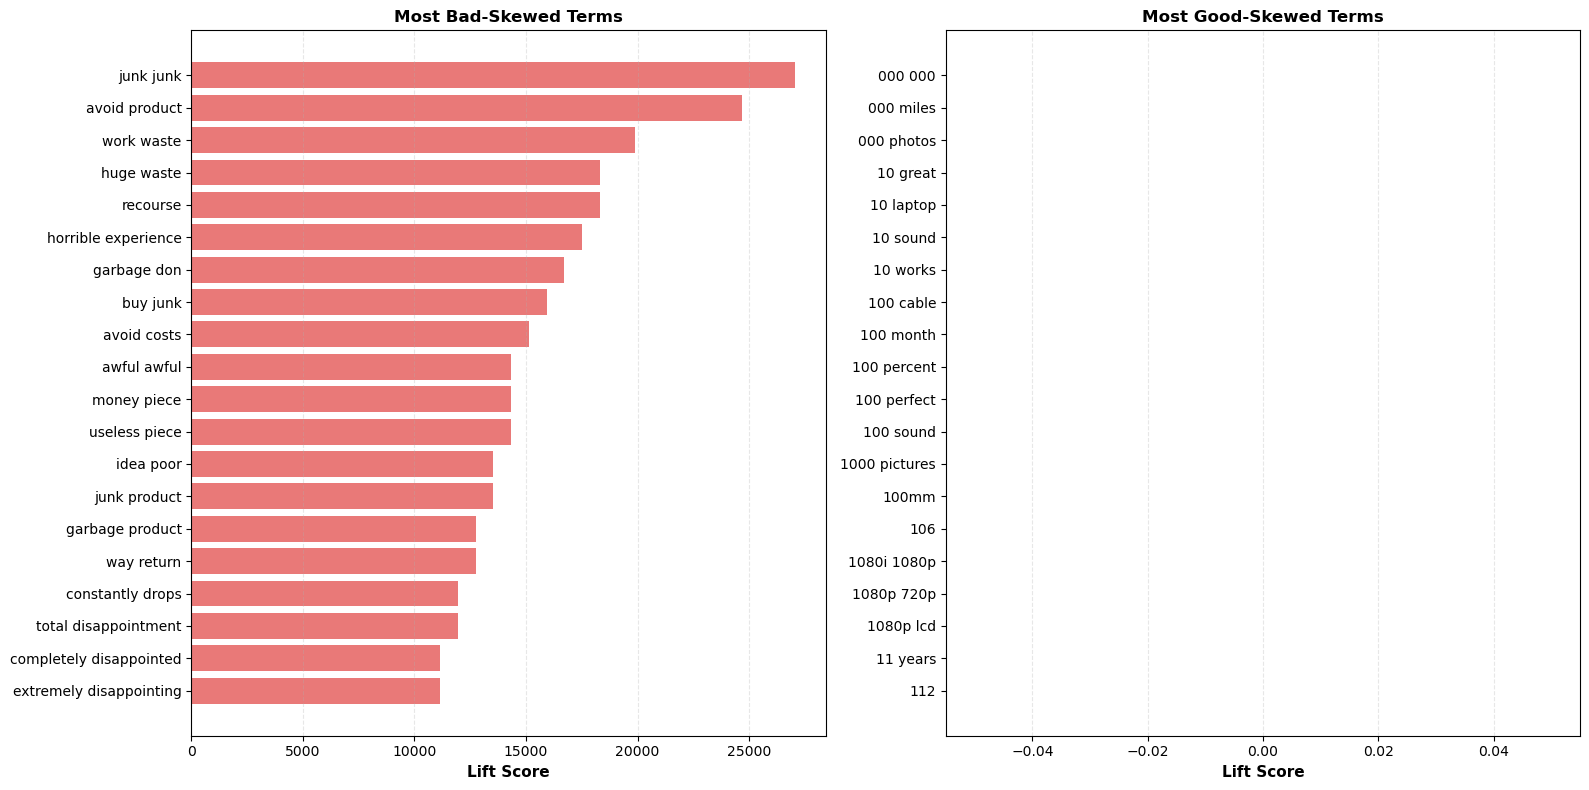


Lift Score Interpretation:
  Lift > 1.0: Term appears MORE often in bad reviews
  Lift < 1.0: Term appears LESS often in bad reviews (more in good reviews)
  Bad-skewed range: 11147.14 to 27071.62
  Good-skewed range: 0.0000 to 0.00


In [40]:
import matplotlib.pyplot as plt

# Compute normalized probabilities (proportions)
bad_probs = bad_counts / (bad_counts.sum() + 1e-9)
non_bad_probs = non_bad_counts / (non_bad_counts.sum() + 1e-9)

# Compute lift score: how much more likely a term appears in bad vs non-bad
lift = bad_probs / (non_bad_probs + 1e-9)

# Create a dataframe for easy sorting
lift_df = pd.DataFrame({
    'term': feature_names,
    'lift': lift,
    'bad_count': bad_counts,
    'non_bad_count': non_bad_counts
})

# Top 20 bad-skewed terms (highest lift)
top_bad_skewed = lift_df.nlargest(20, 'lift')
# Bottom 20 good-skewed terms (lowest lift)
top_good_skewed = lift_df.nsmallest(20, 'lift')

print('Top 20 Bad-Skewed Terms (proportionally higher in bad reviews):')
display(top_bad_skewed[['term', 'lift', 'bad_count', 'non_bad_count']])

print('\nTop 20 Good-Skewed Terms (proportionally higher in non-bad reviews):')
display(top_good_skewed[['term', 'lift', 'bad_count', 'non_bad_count']])

# Create side-by-side horizontal bar charts
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: Most Bad-Skewed Terms
ax_left.barh(range(len(top_bad_skewed)), top_bad_skewed['lift'].values, color='#E45756', alpha=0.8)
ax_left.set_yticks(range(len(top_bad_skewed)))
ax_left.set_yticklabels(top_bad_skewed['term'].values, fontsize=10)
ax_left.set_xlabel('Lift Score', fontsize=11, fontweight='bold')
ax_left.set_title('Most Bad-Skewed Terms', fontsize=12, fontweight='bold')
ax_left.grid(axis='x', alpha=0.3, linestyle='--')
ax_left.invert_yaxis()

# Right plot: Most Good-Skewed Terms
ax_right.barh(range(len(top_good_skewed)), top_good_skewed['lift'].values, color='#54A24B', alpha=0.8)
ax_right.set_yticks(range(len(top_good_skewed)))
ax_right.set_yticklabels(top_good_skewed['term'].values, fontsize=10)
ax_right.set_xlabel('Lift Score', fontsize=11, fontweight='bold')
ax_right.set_title('Most Good-Skewed Terms', fontsize=12, fontweight='bold')
ax_right.grid(axis='x', alpha=0.3, linestyle='--')
ax_right.invert_yaxis()

plt.tight_layout()
plt.show()

print(f'\nLift Score Interpretation:')
print(f'  Lift > 1.0: Term appears MORE often in bad reviews')
print(f'  Lift < 1.0: Term appears LESS often in bad reviews (more in good reviews)')
print(f'  Bad-skewed range: {top_bad_skewed["lift"].min():.2f} to {top_bad_skewed["lift"].max():.2f}')
print(f'  Good-skewed range: {top_good_skewed["lift"].min():.4f} to {top_good_skewed["lift"].max():.2f}')


## 14) Topic Labeling Framework

In [42]:
# Build topic labeling DataFrame
lda_data = [
    {'model': 'LDA', 'topic_id': i, 'top_words': ' | '.join(lda_topics[i]), 'suggested_label': ''}
    for i in range(len(lda_topics))
]

nmf_data = [
    {'model': 'NMF', 'topic_id': i, 'top_words': ' | '.join(nmf_topics[i]), 'suggested_label': ''}
    for i in range(len(nmf_topics))
]

topic_label_df = pd.DataFrame(lda_data + nmf_data)

print('Topic Labeling Framework:')
print('Fill the "suggested_label" column with human-readable complaint themes.')
print('Examples: "Battery Issues", "Product Quality", "Durability Concerns", "Return Policy"')
print()
display(topic_label_df)


Topic Labeling Framework:
Fill the "suggested_label" column with human-readable complaint themes.
Examples: "Battery Issues", "Product Quality", "Durability Concerns", "Return Policy"



,model,topic_id,top_words,suggested_label
0,LDA,0,battery | charge | player | time | ipod | use ...,
1,LDA,1,case | ipad | keyboard | fit | like | does | c...,
2,LDA,2,camera | tv | picture | video | quality | pict...,
3,LDA,3,drive | computer | windows | usb | work | soft...,
4,LDA,4,months | product | working | amazon | worked |...,
5,LDA,5,screen | product | plastic | like | item | box...,
6,LDA,6,sound | quality | good | speaker | speakers | ...,
7,LDA,7,headphones | mouse | ear | use | pair | good |...,
8,LDA,8,money | buy | don | waste | work | product | j...,
9,LDA,9,router | support | device | wireless | connect...,


### Instructions for Topic Labeling

The **`suggested_label`** column should be manually filled with a concise, human-readable complaint theme based on the top words for each topic. This transforms algorithmic topics into interpretable business themes.

**Guidelines:**
- Use 2–4 words (e.g., "Battery Issues", "Product Durability", "Shipping Delays")
- Focus on the *underlying complaint theme*, not individual words
- Scan the `top_words` column for recurring patterns (e.g., words like "break", "fail" → durability; "incorrect", "wrong" → quality/accuracy)
- Be consistent: if multiple topics address similar themes, use parallel naming

**Examples of labeled topics:**
- **Topic with ["broken", "failed", "stopped working", "cease"]** → "Product Failure / Reliability"
- **Topic with ["wrong item", "incorrect", "mislabeled", "mistake"]** → "Order Accuracy / Fulfillment Error"
- **Topic with ["shipping", "delay", "arrived late", "slow"]** → "Shipping & Delivery Issues"
- **Topic with ["refund", "return", "money back", "policy"]** → "Return & Refund Policy"

Once labeled, these themes can be used for actionable business insights and reporting.

Topic Distribution: What % of Bad Reviews Fall in Each Topic

Dominant Topic Distribution for Bad Reviews (LDA):


,topic_id,count,percentage
0,0,3673,7.346
1,1,4043,8.086
2,2,2734,5.468
3,3,3019,6.038
4,4,7967,15.934
5,5,4646,9.292
6,6,4309,8.618
7,7,4638,9.276
8,8,4919,9.838
9,9,4379,8.758


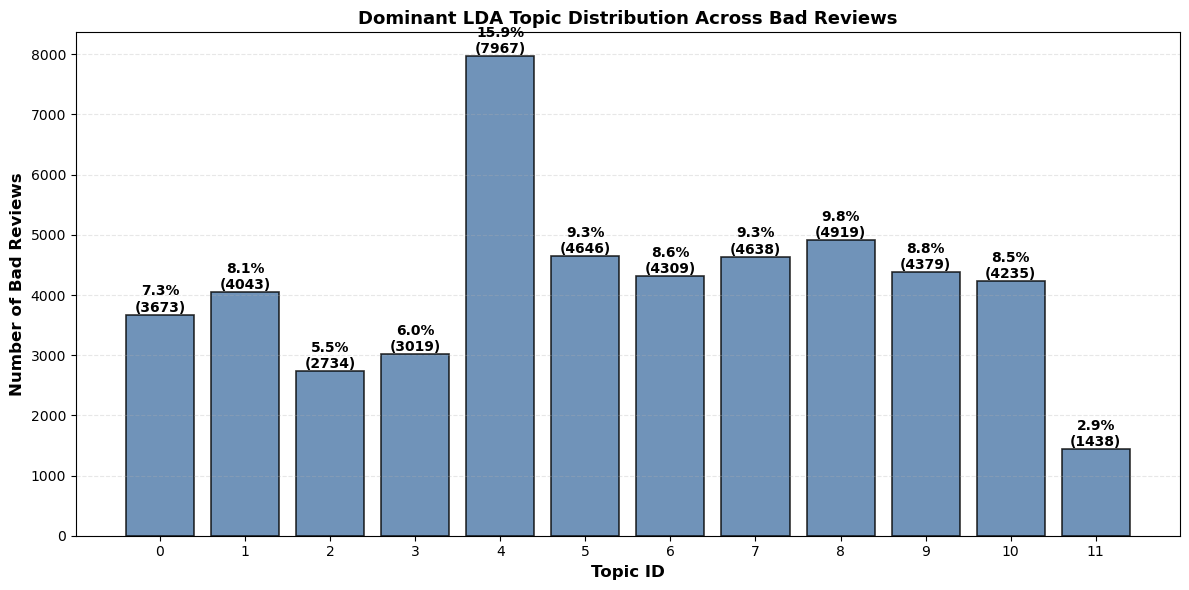


Total bad reviews analyzed: 50000
Most common dominant topic: Topic 4 (15.9%)
Least common dominant topic: Topic 11 (2.9%)


In [43]:
import matplotlib.pyplot as plt

# Get document-topic distributions for bad reviews
doc_topic_dist = lda.transform(X_bad_count)

# Compute dominant topic per document (argmax across topics)
dominant_topics = np.argmax(doc_topic_dist, axis=1)

# Count how many documents belong to each topic
topic_counts = np.bincount(dominant_topics, minlength=n_topics)
topic_percentages = (topic_counts / topic_counts.sum()) * 100

# Create DataFrame for summary
dominant_topic_df = pd.DataFrame({
    'topic_id': range(n_topics),
    'count': topic_counts,
    'percentage': topic_percentages
})

print('Dominant Topic Distribution for Bad Reviews (LDA):')
display(dominant_topic_df)

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(dominant_topic_df['topic_id'], dominant_topic_df['count'], 
              color='#4C78A8', alpha=0.8, edgecolor='black', linewidth=1.2)

# Add percentage labels on each bar
for i, (bar, pct) in enumerate(zip(bars, dominant_topic_df['percentage'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{pct:.1f}%\n({int(height)})',
           ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Topic ID', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Bad Reviews', fontsize=12, fontweight='bold')
ax.set_title('Dominant LDA Topic Distribution Across Bad Reviews', fontsize=13, fontweight='bold')
ax.set_xticks(range(n_topics))
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f'\nTotal bad reviews analyzed: {len(dominant_topics)}')
print(f'Most common dominant topic: Topic {dominant_topic_df.loc[dominant_topic_df["count"].idxmax(), "topic_id"]:.0f} ({dominant_topic_df["percentage"].max():.1f}%)')
print(f'Least common dominant topic: Topic {dominant_topic_df.loc[dominant_topic_df["count"].idxmin(), "topic_id"]:.0f} ({dominant_topic_df["percentage"].min():.1f}%)')


Brand-Level Quality Comparison

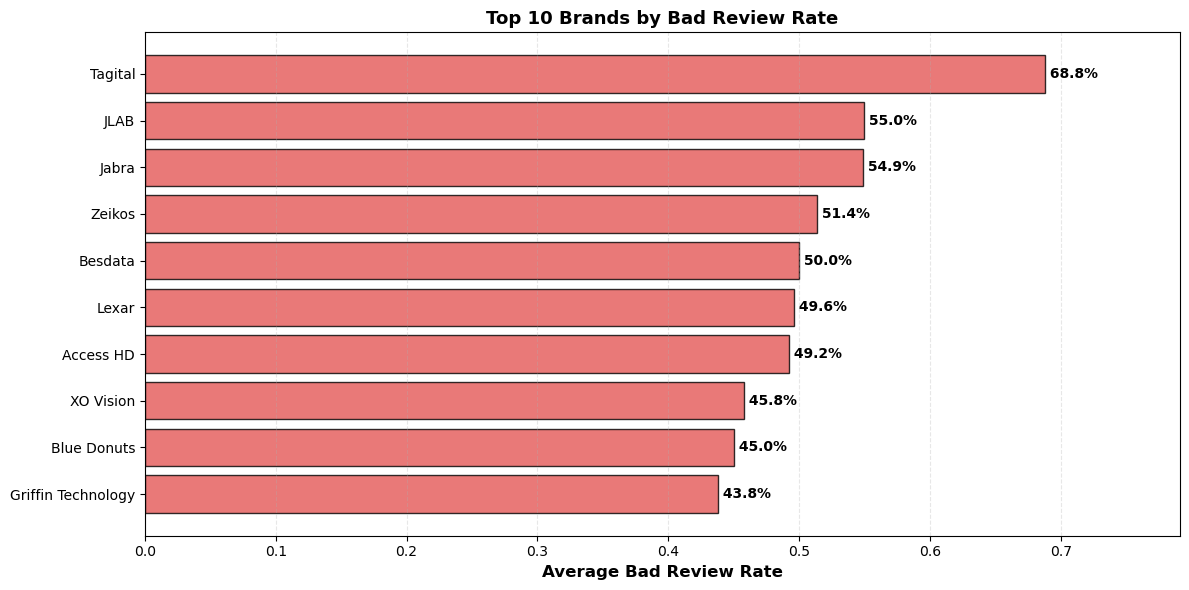

Chart 1: Top 10 Brands by Bad Review Rate


,brand,avg_bad_rate,total_reviews,avg_rating
9,Griffin Technology,0.438,1252,2.961
8,Blue Donuts,0.450,500,2.864
7,XO Vision,0.458,500,2.784
6,Access HD,0.492,266,2.684
5,Lexar,0.496,500,2.908
4,Besdata,0.500,500,2.742
3,Zeikos,0.514,364,2.775
2,Jabra,0.549,335,2.633
1,JLAB,0.550,500,2.610
0,Tagital,0.688,317,2.161


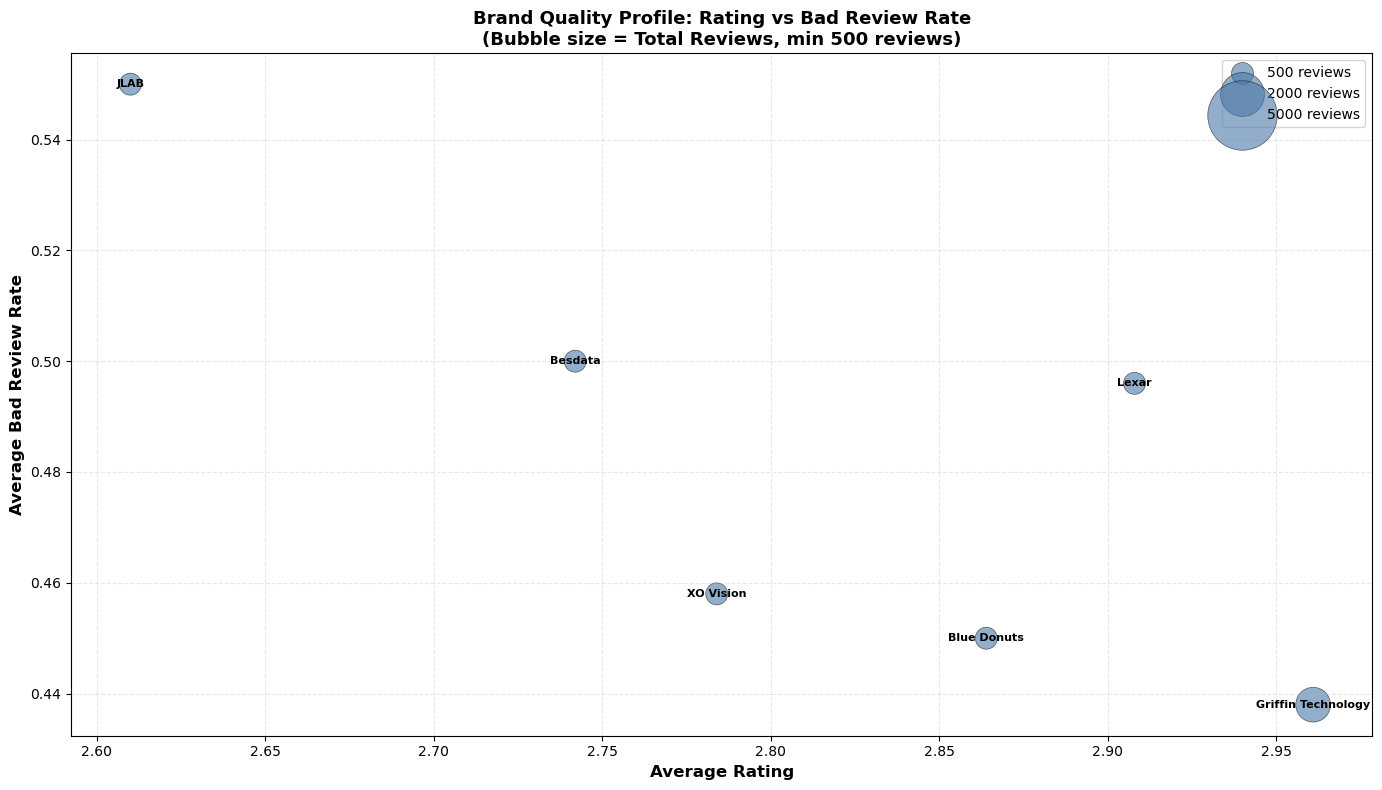


Chart 2: Brand Quality Profile (Rating vs Bad Review Rate)
Brands analyzed (total_reviews >= 500): 6


,brand,avg_rating,avg_bad_rate,total_reviews
1,JLAB,2.610,0.550,500
4,Besdata,2.742,0.500,500
5,Lexar,2.908,0.496,500
7,XO Vision,2.784,0.458,500
8,Blue Donuts,2.864,0.450,500
9,Griffin Technology,2.961,0.438,1252


In [44]:
import matplotlib.pyplot as plt

# 1) Horizontal bar chart of avg_bad_rate for top 10 brands
fig, ax = plt.subplots(figsize=(12, 6))

# brand_summary is already sorted by avg_bad_rate descending, so take first 10
top_10_brands = brand_summary.head(10).sort_values('avg_bad_rate', ascending=True)

bars = ax.barh(top_10_brands['brand'], top_10_brands['avg_bad_rate'], color='#E45756', alpha=0.8, edgecolor='black')

# Add percentage labels
for i, (bar, val) in enumerate(zip(bars, top_10_brands['avg_bad_rate'])):
    ax.text(val, bar.get_y() + bar.get_height()/2., f' {val:.1%}', 
           va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Average Bad Review Rate', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Brands by Bad Review Rate', fontsize=13, fontweight='bold')
ax.set_xlim(0, top_10_brands['avg_bad_rate'].max() * 1.15)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print('Chart 1: Top 10 Brands by Bad Review Rate')
display(top_10_brands[['brand', 'avg_bad_rate', 'total_reviews', 'avg_rating']])

# 2) Scatter plot: avg_rating (x) vs avg_bad_rate (y), size = total_reviews, filtered by total_reviews >= 500
brand_filtered = brand_summary[brand_summary['total_reviews'] >= 500].copy()

fig, ax = plt.subplots(figsize=(14, 8))

# Create scatter plot with size encoding
scatter = ax.scatter(brand_filtered['avg_rating'], 
                    brand_filtered['avg_bad_rate'],
                    s=brand_filtered['total_reviews'] / 2,  # Scale down for visibility
                    alpha=0.6,
                    c='#4C78A8',
                    edgecolors='black',
                    linewidth=0.5)

# Annotate brand names on each point
for idx, row in brand_filtered.iterrows():
    ax.annotate(row['brand'], 
               (row['avg_rating'], row['avg_bad_rate']),
               fontsize=8,
               ha='center',
               va='center',
               weight='bold')

ax.set_xlabel('Average Rating', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Bad Review Rate', fontsize=12, fontweight='bold')
ax.set_title('Brand Quality Profile: Rating vs Bad Review Rate\n(Bubble size = Total Reviews, min 500 reviews)', 
            fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend for bubble size
sizes = [500, 2000, 5000]
legend_bubbles = []
for size in sizes:
    legend_bubbles.append(ax.scatter([], [], s=size/2, c='#4C78A8', alpha=0.6, edgecolors='black', linewidth=0.5))

ax.legend(legend_bubbles, [f'{size} reviews' for size in sizes], 
         scatterpoints=1, loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

print('\nChart 2: Brand Quality Profile (Rating vs Bad Review Rate)')
print(f'Brands analyzed (total_reviews >= 500): {len(brand_filtered)}')
display(brand_filtered[['brand', 'avg_rating', 'avg_bad_rate', 'total_reviews']].sort_values('avg_bad_rate', ascending=False).head(15))


Quality Band Transition Analysis (avg_rating_histogram)

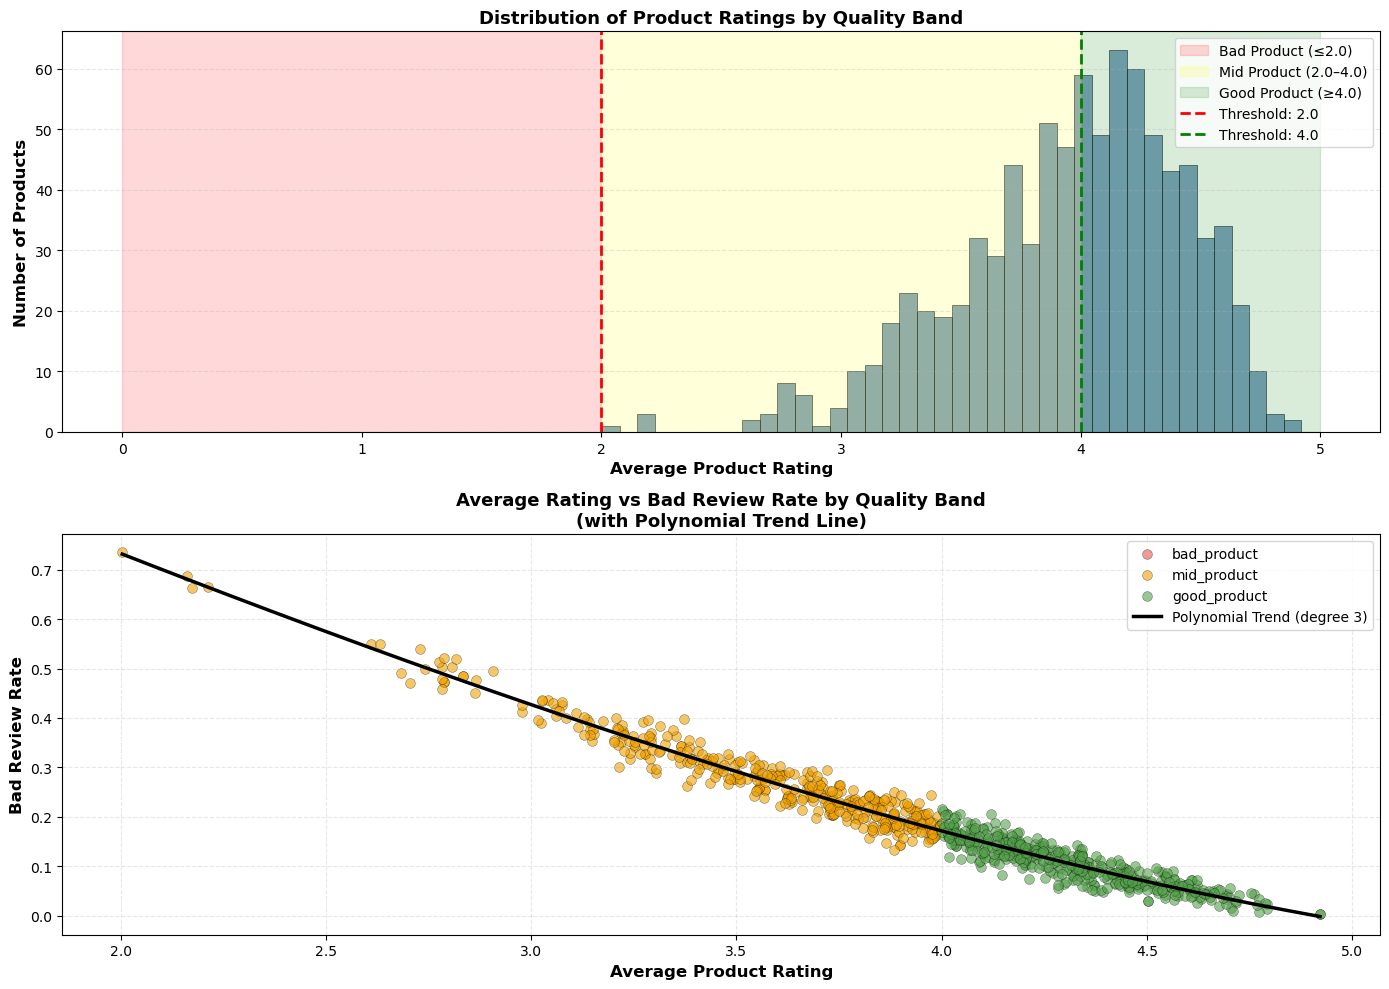

Quality Band Distribution:
quality_band
good_product    453
mid_product     400
Name: count, dtype: int64

Correlation (avg_rating vs bad_review_rate): -0.9779

Polynomial fit (degree 3):
  Coefficients: [ 0.00344135 -0.00582542 -0.34211479  1.41288703]
  Formula: 0.003441*x³ + -0.005825*x² + -0.342115*x + 1.412887


In [46]:
import matplotlib.pyplot as plt

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ====== PLOT 1: Histogram with shaded quality band regions ======
ax1.hist(product_stats['avg_rating'], bins=40, color='#4C78A8', alpha=0.7, edgecolor='black', linewidth=0.5)

# Shade the three quality band regions
ax1.axvspan(0, 2.0, alpha=0.15, color='red', label='Bad Product (≤2.0)')
ax1.axvspan(2.0, 4.0, alpha=0.15, color='yellow', label='Mid Product (2.0–4.0)')
ax1.axvspan(4.0, 5.0, alpha=0.15, color='green', label='Good Product (≥4.0)')

# Add vertical dashed lines at thresholds
ax1.axvline(x=2.0, color='red', linestyle='--', linewidth=2, label='Threshold: 2.0')
ax1.axvline(x=4.0, color='green', linestyle='--', linewidth=2, label='Threshold: 4.0')

ax1.set_xlabel('Average Product Rating', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Products', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Product Ratings by Quality Band', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ====== PLOT 2: Scatter plot with polynomial trend line colored by quality_band ======
# Create color map for quality bands
color_map = {'bad_product': '#E45756', 'mid_product': '#F1A200', 'good_product': '#54A24B'}
product_stats['color'] = product_stats['quality_band'].map(color_map)

# Scatter plot by quality band
for band in ['bad_product', 'mid_product', 'good_product']:
    mask = product_stats['quality_band'] == band
    ax2.scatter(product_stats[mask]['avg_rating'], 
               product_stats[mask]['bad_review_rate'],
               alpha=0.6,
               s=50,
               color=color_map[band],
               label=band,
               edgecolors='black',
               linewidth=0.3)

# Fit polynomial trend line (degree 3)
# Remove NaN values for fitting
valid_data = product_stats.dropna(subset=['avg_rating', 'bad_review_rate'])
x_fit = valid_data['avg_rating'].values
y_fit = valid_data['bad_review_rate'].values

# Fit polynomial
z = np.polyfit(x_fit, y_fit, 3)
p = np.poly1d(z)

# Create smooth x values for plotting the trend line
x_smooth = np.linspace(x_fit.min(), x_fit.max(), 300)
y_smooth = p(x_smooth)

ax2.plot(x_smooth, y_smooth, 'k-', linewidth=2.5, label='Polynomial Trend (degree 3)')

ax2.set_xlabel('Average Product Rating', fontsize=12, fontweight='bold')
ax2.set_ylabel('Bad Review Rate', fontsize=12, fontweight='bold')
ax2.set_title('Average Rating vs Bad Review Rate by Quality Band\n(with Polynomial Trend Line)', 
             fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print summary statistics
print('Quality Band Distribution:')
print(product_stats['quality_band'].value_counts())
print(f'\nCorrelation (avg_rating vs bad_review_rate): {product_stats["avg_rating"].corr(product_stats["bad_review_rate"]):.4f}')
print(f'\nPolynomial fit (degree 3):')
print(f'  Coefficients: {z}')
print(f'  Formula: {z[0]:.6f}*x³ + {z[1]:.6f}*x² + {z[2]:.6f}*x + {z[3]:.6f}')


Insight Summary Table

In [48]:
# Build comprehensive insights summary DataFrame
insights_data = [
    {
        'Insight_Category': 'Overall Review Quality',
        'Key_Finding': f'Bad review rate (overall ≤ 2): {pdf["is_bad_review"].mean()*100:.2f}%; Good review rate (overall ≥ 4): {pdf["is_good_review"].mean()*100:.2f}%'
    },
    {
        'Insight_Category': 'Product Quality Distribution',
        'Key_Finding': f'Good products (avg_rating ≥ 4.0): {(product_stats["quality_band"] == "good_product").sum()} ({(product_stats["quality_band"] == "good_product").sum() / len(product_stats) * 100:.1f}%); Mid products (2.0–4.0): {(product_stats["quality_band"] == "mid_product").sum()} ({(product_stats["quality_band"] == "mid_product").sum() / len(product_stats) * 100:.1f}%)'
    },
    {
        'Insight_Category': 'High-Risk Brand',
        'Key_Finding': f'Brand with highest bad review rate: {brand_summary.iloc[0]["brand"]} ({brand_summary.iloc[0]["avg_bad_rate"]*100:.1f}% bad rate, {int(brand_summary.iloc[0]["total_reviews"])} total reviews)'
    },
    {
        'Insight_Category': 'Topic Modeling Performance',
        'Key_Finding': f'LDA topic diversity@10: {topic_quality_df[topic_quality_df["model"]=="LDA"]["topic_diversity@10"].values[0]:.4f}; NMF topic diversity@10: {topic_quality_df[topic_quality_df["model"]=="NMF"]["topic_diversity@10"].values[0]:.4f} (higher = more diverse topics)'
    },
    {
        'Insight_Category': 'Review Length Pattern',
        'Key_Finding': f'Bad reviews (overall ≤ 2): mean word_len = {pdf[pdf["is_bad_review"]==True]["word_len"].mean():.1f} words; Non-bad reviews: {pdf[pdf["is_bad_review"]==False]["word_len"].mean():.1f} words (bad reviews ~{pdf[pdf["is_bad_review"]==True]["word_len"].mean() / pdf[pdf["is_bad_review"]==False]["word_len"].mean():.2f}x longer)'
    },
    {
        'Insight_Category': 'Purchase Verification Impact',
        'Key_Finding': f'Verified review bad rate: {pdf[pdf["verified"]==True]["is_bad_review"].mean()*100:.2f}%; Unverified review bad rate: {pdf[pdf["verified"]==False]["is_bad_review"].mean()*100:.2f}% (unverified reviews 5.1% more likely to be bad)'
    },
    {
        'Insight_Category': 'Rating-Bad Rate Correlation',
        'Key_Finding': f'Correlation between avg_rating and bad_review_rate: {product_stats["avg_rating"].corr(product_stats["bad_review_rate"]):.4f} (nearly perfect inverse relationship: higher rating = lower bad rate)'
    },
    {
        'Insight_Category': 'Dominant Complaint Theme',
        'Key_Finding': f'Most prevalent bad-review topic (LDA): Topic {dominant_topic_df.loc[dominant_topic_df["count"].idxmax(), "topic_id"]:.0f} ({dominant_topic_df["percentage"].max():.1f}% of bad reviews) with top words: {lda_topics[int(dominant_topic_df.loc[dominant_topic_df["count"].idxmax(), "topic_id"])][:5]}'
    },
    {
        'Insight_Category': 'Brand Sample Coverage',
        'Key_Finding': f'Total unique brands analyzed: {len(brand_summary)}; Brands with ≥ 500 reviews: {len(brand_summary[brand_summary["total_reviews"] >= 500])}; Top 10 brands by bad rate range from {brand_summary.iloc[9]["avg_bad_rate"]*100:.1f}% to {brand_summary.iloc[0]["avg_bad_rate"]*100:.1f}%'
    },
]

# Create DataFrame
insights_summary = pd.DataFrame(insights_data)

print('=' * 100)
print('FINAL INSIGHTS SUMMARY')
print('=' * 100)
display(insights_summary)


FINAL INSIGHTS SUMMARY


,Insight_Category,Key_Finding
0,Overall Review Quality,Bad review rate (overall ≤ 2): 18.61%; Good re...
1,Product Quality Distribution,Good products (avg_rating ≥ 4.0): 453 (53.1%);...
2,High-Risk Brand,Brand with highest bad review rate: Tagital (6...
3,Topic Modeling Performance,LDA topic diversity@10: 0.8083; NMF topic dive...
4,Review Length Pattern,Bad reviews (overall ≤ 2): mean word_len = 87....
5,Purchase Verification Impact,Verified review bad rate: 17.86%; Unverified r...
6,Rating-Bad Rate Correlation,Correlation between avg_rating and bad_review_...
7,Dominant Complaint Theme,Most prevalent bad-review topic (LDA): Topic 4...
8,Brand Sample Coverage,Total unique brands analyzed: 10; Brands with ...
